### Závěrečný projekt - modul Python

V tomto projektu budete analyzovat data ze stránky `www.sreality.cz`. Budete tedy získávat aktuální nabídku bytů ve Zlíně (či ve městě dle vašeho výběru)

## Důležité poznámky před začátkem:
- Mezi requesty vkládejte krátké pauzy (např. pomocí `time.sleep(1-2)`), abyste nezatěžovali server.
- **Struktura notebooku**: Váš notebook by měl být přehledně strukturovaný pomocí markdown buněk s nadpisy a komentářů v kódu, které vysvětlují vaše kroky.

## Projekt se dělí na 3 části:

### 1. WebScraping
Pomocí knihovny `BeautifulSoup` získejte **všechny aktuální inzerce bytů** v daném městě. 

**Poznámky:**
- Web scraping musí zahrnovat **všechny stránky** výsledků (pagination), ne pouze první stránku
- Získáte **tyto** informace: 
  - `URL odkaz bytu`
  - `Rozměry bytu` (v m²)
  - `Dispozice bytu` (1+1, 2+kk, atp.)
  - `Cena bytu` (v Kč)
  - `Lokace bytu` (Ulice + město)

**Očekávaný formát dat:**
- **Uložte surová data do CSV souboru** s názvem `{vašeJméno}_surova_data.csv` (tento soubor použijete v další části)

### 2. Datová analýza - ETL proces (Extract, Transform, Load)
V této fázi prověďte processing dat tak, aby obsahovala příslušné datové typy a byla připravená pro analýzu.

**Úkoly:**
- **Načtení dat:**
  - Načtěte surová data z CSV souboru `{vašeJméno}_surova_data.csv`, který jste vytvořili v části 1
  - Zobrazte základní informace o načtených datech (počet řádků, sloupců, náhled dat, datové typy)
  
- **Čištění dat:**
  - Ověřte a opravte datové typy (cena jako číselný typ, rozměry jako číselný typ)
  - Zpracujte chybějící hodnoty (rozhodněte se, zda je odstranit nebo nahradit, a zdůvodněte)
  - Rozdělte lokaci na samostatné sloupce: `Ulice` a `Město`
  
- **Export dat:**
  - Zprocesovaná a vyčištěná data vyexportujte do `.csv` souboru s názvem `{vašeJméno}_zdrojová_data.csv`
  - Před exportem zobrazte základní statistiku o vyčištěných datech (počet řádků, sloupců, základní statistiky)

### 3. Datová analýza - analýza dat
Třetí část začněte tak, že si do dataframe nahrajete vyčištěná data z CSV souboru `{vašeJméno}_zdrojová_data.csv`, který jste vytvořili v části 2.

**Analytické dotazy:**
1. `Jaká je průměrná cena bytů?` (uveďte i medián pro srovnání)
2. `Jaká je průměrná cena bytů pro každou dispozici (1+1, 2+1, atp.)? Zobrazte i na grafu.`
3. `Jaká je průměrná velikost bytu pro každou dispozici? Zobrazte i na grafu.`
4. `Existuje ulice, kde je vyšší koncentrace dražších bytů?` (Definujte "dražší" jako byty nad průměrnou cenou. Zobrazte top 5 ulic s nejvyšší průměrnou cenou, pokud máte dostatek dat.)
5. `Jaký typ dispozice je v daném městě nejčastěji inzerován? Který to je? Proč myslíte, že tomu tak je?` (Zobrazte na grafu - např. bar chart nebo pie chart)
6. `Existují zde inzerce bytů, které stojí více než 20.000,- Kč? Pokud ano, jsou v této cenové hladině inzerovány i maximálně dvoupokojové byty (2+1/2+kk)?`
7. `Zjištěte minimální a maximální cenu inzerce pro každou dispozici bytu. Která dispozice má největší rozptyl mezi minimální a maximální inzerovanou cenou?` (Zobrazte i na grafu)

**Poznámky k analýze:**
- Všechny odpovědi doplňte komentáři a interpretací výsledků
- Pro vizualizace použijte `matplotlib` nebo `seaborn`
- Grafy by měly mít popisky os, titulky a být čitelné

## Odevzdání:
- Dotazy zodpovězte ve vašem pracovním notebooku s komentáři a interpretacemi
- Výsledný soubor nahrajte na GitHub
- V README na GitHubu uveďte stručný popis projektu a hlavní zjištění

## Tipy a užitečné knihovny

**Doporučené knihovny:**
```python
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
```

**Užitečné tipy:**
- Pro pagination: Zkontrolujte, jak stránka implementuje stránkování (URL parametr `?strana=X` nebo jiný mechanismus)
- Pro čištění dat: `pd.to_numeric()` s parametrem `errors='coerce'` pro konverzi cen a rozměrů
- Pro rozdělení lokace: `str.split()`

In [ ]:
from bs4 import BeautifulSoup
import requests

strana = 1
response = requests.get(f'https://www.sreality.cz/hledani/pronajem/byty/zlin?strana={strana}').text

### 1. WebScraping - spracovanie

In [ ]:
# importujem si potrebne kniznice (BeautifulSoup, requests, time)

from bs4 import BeautifulSoup
import requests
import time


dalsi_stranka = True
strana = 1

# pripravim si prazdny list, kam budem ukladat vsetky prenajmy
zoznam_bytov = []

# while cyklus bude prechadzat vsetky stranky na www.sreality.cz, ktore mam pod filtrom
while dalsi_stranka:

    # ziskam HTML kod z webu
    response = requests.get(f"https://www.sreality.cz/hledani/pronajem/byty?strana={strana}&region=Zl%C3%ADn&region-id=3045&region-typ=municipality").text

    print(f'Začínám scrapovat stránku číslo {strana} ...')

    # z HTML kodu urobim BeautifulSoup objekt
    soup = BeautifulSoup(response, "html.parser")

    #ziskam HTML kod vsetkych inzercii do listu (1 prvok = 1 inzercia)
    pronajmy = soup.find_all("li", "MuiGrid2-root")

    # budem prechadzat jednotlive inzercie v liste prenajmov a hladat url odkaz, dispozice bytu, rozmery bytu, lokace bytu, cenu bytu
    for pronajem in pronajmy:

        # URL odkaz
        if pronajem.find('a', 'MuiTypography-root MuiTypography-inherit MuiLink-root MuiLink-underlineAlways css-1s6ohwi') is None:
            url = None
        else:
            url = pronajem.find('a', "MuiTypography-root MuiTypography-inherit MuiLink-root MuiLink-underlineAlways css-1s6ohwi")['href']
                
            full_url = 'https://www.sreality.cz' + url
            # print(full_url)

        print(f'Procházím link: {url} ...')

        # Dispozice bytu
        if pronajem.find('p', 'css-d7upve') is None:
            dispozice = None
        else:
            dispozice = pronajem.find_all('p', 'css-d7upve')[0].text.replace("SLEVA: Pronájem bytu", "").replace("Pronájem bytu", "").replace("m²", "").replace("Kč/měsíc", "").strip().split(' ')[0]
            #  print(f'Dispozice bytu: {dispozice}')

        # Rozmery bytu
        if pronajem.find('p', 'css-d7upve') is None:
            rozmery = None
        else:
            rozmery = pronajem.find_all('p', 'css-d7upve')[0].text.replace("SLEVA: Pronájem bytu", "").replace("Pronájem bytu", "").replace("m²", "").strip().split(' ')[1]
            #  print(f'rozmery bytu: {rozmery}')

        # Lokace bytu_mesto
        if pronajem.find('p', 'css-d7upve') is None:
            lokace_bytu_mesto = None
        else:
            lokace_bytu_mesto = pronajem.find_all('p', 'css-d7upve')[1].text.strip().split(",")[-1]
            lokace_bytu_ulice = pronajem.find_all('p', 'css-d7upve')[1].text.strip().split(",")[0]

        # Cena bytu
         # Cena bytu
        if pronajem.find('p', 'css-ca9wwd') is None:
            cena_bytu = None
        else:
            cena_bytu= pronajem.find_all('p', 'css-ca9wwd')[0].text.replace("Kč/měsíc", "").replace("\xa0", "").strip()
            #print(f'ceny bytu: {cena_bytu}')

       
       # vsetky ziskane informacie pre kazdu inzerciu pripojim do listu vsetkych inzercii
        zoznam_bytov.append(
            {
                "URL odkaz bytu": full_url,
                "Rozmery bytu": rozmery,
                "Dispozice bytu": dispozice,
                "Cena bytu": cena_bytu,
                "Lokace bytu_ulica": lokace_bytu_ulice,
                "Lokace bytu_mesto": lokace_bytu_mesto
            }
        )

    # Nastavím si časovu prodlevu
    time.sleep(1)

    # Kontrolujem, ci existuje dalsia stranka
    if soup.find('button', attrs={'aria-label': 'Další stránka'}) is None:
        print('Nenašel jsem další stránku')
        dalsi_stranka = False
    else:
        print('Našel jsem další stránku, pokračuji na stránku', strana + 1)
        strana += 1

In [ ]:
len(zoznam_bytov)


In [ ]:
# importujem pandas a ukladam data do csv suboru
import pandas as pd
df = pd.DataFrame(zoznam_bytov)
df.to_csv('Katarina_Kocakova_surova_data.csv', sep=',', index=False)

### 2. Datová analýza - ETL proces (Extract, Transform, Load)

**Načtení dat:**

In [2]:
# načítam surove data z csv suboru vytvoreneho v 1. kroku
import pandas as pd
df = pd.read_csv("Katarina_Kocakova_surova_data.csv")

# zobrazujem nahled dat na prvych 10 riadkov z tabulky
df.head(10)

,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto
0,https://www.sreality.cz/detail/pronajem/byt/1+...,35.0,1+kk,12900,Devadesátá,Zlín
1,https://www.sreality.cz/detail/pronajem/byt/1+...,28.0,1+kk,10000,Nad Stráněmi,Zlín
2,https://www.sreality.cz/detail/pronajem/byt/2+...,45.0,2+kk,9500,V Dolině,Zlín - Jaroslavice
3,https://www.sreality.cz/detail/pronajem/byt/2+...,60.0,2+1,16000,třída Tomáše Bati,Zlín
4,https://www.sreality.cz/detail/pronajem/byt/2+...,56.0,2+1,13000,Dlouhá,Zlín
5,https://www.sreality.cz/detail/pronajem/byt/1+...,58.0,1+kk,Cena na vyžádání,J. A. Bati,Zlín
6,https://www.sreality.cz/detail/pronajem/byt/1+...,31.0,1+kk,Cena na vyžádání,J. A. Bati,Zlín
7,https://www.sreality.cz/detail/pronajem/byt/1+...,47.0,1+kk,12900,Březnická,Zlín
8,https://www.sreality.cz/detail/pronajem/byt/1+...,NaN,NaN,NaN,Březnická,NaN
9,https://www.sreality.cz/detail/pronajem/byt/2+...,65.0,2+1,20000,Mokrá II,Zlín - Mladcová


In [3]:
# zobrazujem datove typy stlpcov
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   URL odkaz bytu     180 non-null    object 
 1   Rozmery bytu       157 non-null    float64
 2   Dispozice bytu     157 non-null    object 
 3   Cena bytu          157 non-null    object 
 4   Lokace bytu_ulica  180 non-null    object 
 5   Lokace bytu_mesto  157 non-null    object 
dtypes: float64(1), object(5)
memory usage: 8.6+ KB


In [4]:
# zobrazujem pocet riadkov a pocet stlpcov

pocet_riadkov = df.shape[0]
pocet_stlpcov = df.shape[1]

print(f"Tabulka ma {pocet_riadkov} riadkov a {pocet_stlpcov} stlpcov. ")

Tabulka ma 180 riadkov a 6 stlpcov. 


**Čištění dat:**

In [5]:
# Zmazanie riadkov s nulovou hodnotou (reklamy) - nulova hodnota v stlpci rozmery bytu

df.dropna(subset=["Rozmery bytu"],inplace=True)

In [6]:
# Zobrazenie informacii o DataFramu bez reklam, iba inzercie
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157 entries, 0 to 178
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   URL odkaz bytu     157 non-null    object 
 1   Rozmery bytu       157 non-null    float64
 2   Dispozice bytu     157 non-null    object 
 3   Cena bytu          157 non-null    object 
 4   Lokace bytu_ulica  157 non-null    object 
 5   Lokace bytu_mesto  157 non-null    object 
dtypes: float64(1), object(5)
memory usage: 8.6+ KB


In [7]:
# Vyfiltrovane 3 riadky, kde je "Cena na vyžádání"
df.loc[df["Cena bytu"] == "Cena na vyžádání"] 


,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto
5,https://www.sreality.cz/detail/pronajem/byt/1+...,58.0,1+kk,Cena na vyžádání,J. A. Bati,Zlín
6,https://www.sreality.cz/detail/pronajem/byt/1+...,31.0,1+kk,Cena na vyžádání,J. A. Bati,Zlín
39,https://www.sreality.cz/detail/pronajem/byt/4+...,130.0,4+1,Cena na vyžádání,Pod Vrškem,Zlín


In [8]:
# Nahradenie "Cena na vyžádání" prazdnou hodnotou, aby som mohla zmenit (pretypovat) datovy typ stlpca Cena bytu z object na float
df['Cena bytu'] = df['Cena bytu'].replace('Cena na vyžádání', None)

In [9]:
# kontrola, že už nemam ziaden riadok s "Cena na vyžádání"
df.loc[df["Cena bytu"] == "Cena na vyžádání"] 

,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto


In [10]:
# pretypovanie stlpca Cena bytu na float
df['Cena bytu'] = df['Cena bytu'].astype(float)

In [11]:
# odfiltrovanie Dispozicie bytu "pokoje" nakolko by nam to skreslovalo analyzu dat a je to iba jeden riadok a my robime analyzu celych bytov

df = df.loc[df["Dispozice bytu"] != "pokoje"]


**Export dat:**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 0 to 178
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   URL odkaz bytu     156 non-null    object 
 1   Rozmery bytu       156 non-null    float64
 2   Dispozice bytu     156 non-null    object 
 3   Cena bytu          153 non-null    float64
 4   Lokace bytu_ulica  156 non-null    object 
 5   Lokace bytu_mesto  156 non-null    object 
dtypes: float64(2), object(4)
memory usage: 8.5+ KB


In [13]:
# zobrazujem pocet riadkov a pocet stlpcov pre vycistena/zdrojova data

pocet_riadkov = df.shape[0]
pocet_stlpcov = df.shape[1]

print(f"Tabulka ma {pocet_riadkov} riadkov a {pocet_stlpcov} stlpcov. ")

Tabulka ma 156 riadkov a 6 stlpcov. 


In [14]:
# zobrazujem zakladnu statistiku pre ciselne stlpce (rozmery bytu a cenu bytu)
df.describe()

,Rozmery bytu,Cena bytu
count,156.000000,153.000000
mean,54.839744,15424.980392
std,22.929766,4530.529283
min,20.000000,8000.000000
25%,35.000000,12500.000000
50%,52.000000,14200.000000
75%,66.500000,17500.000000
max,143.000000,33000.000000


In [15]:
# ukladam vycistena data do csv suboru

df.to_csv('Katarina_Kocakova_zdrojova_data.csv', index=False)

### 3. Datová analýza - analýza dat

In [2]:
# načítam zdrojova data z csv suboru vytvoreneho v 2. kroku
import pandas as pd
df = pd.read_csv("Katarina_Kocakova_zdrojova_data.csv")

# zobrazujem nahled dat na prvych 10 riadkov z tabulky
df.head(10)

,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto
0,https://www.sreality.cz/detail/pronajem/byt/1+...,35.0,1+kk,12900.0,Devadesátá,Zlín
1,https://www.sreality.cz/detail/pronajem/byt/1+...,28.0,1+kk,10000.0,Nad Stráněmi,Zlín
2,https://www.sreality.cz/detail/pronajem/byt/2+...,45.0,2+kk,9500.0,V Dolině,Zlín - Jaroslavice
3,https://www.sreality.cz/detail/pronajem/byt/2+...,60.0,2+1,16000.0,třída Tomáše Bati,Zlín
4,https://www.sreality.cz/detail/pronajem/byt/2+...,56.0,2+1,13000.0,Dlouhá,Zlín
5,https://www.sreality.cz/detail/pronajem/byt/1+...,58.0,1+kk,NaN,J. A. Bati,Zlín
6,https://www.sreality.cz/detail/pronajem/byt/1+...,31.0,1+kk,NaN,J. A. Bati,Zlín
7,https://www.sreality.cz/detail/pronajem/byt/1+...,47.0,1+kk,12900.0,Březnická,Zlín
8,https://www.sreality.cz/detail/pronajem/byt/2+...,65.0,2+1,20000.0,Mokrá II,Zlín - Mladcová
9,https://www.sreality.cz/detail/pronajem/byt/1+...,20.0,1+kk,14900.0,Vejvanovská,Zlín


**Analytické dotazy:**

1. `Jaká je průměrná cena bytů?` (uveďte i medián pro srovnání)

In [3]:
# vypocitam si priemernu cenu bytov a median bytov a porovnam v F stringu


priemerna_cena_bytov = df["Cena bytu"].mean().round()

median_bytov = df["Cena bytu"].median()

print(f"Priemerná cena bytov je {priemerna_cena_bytov} Kč a medián je {median_bytov} Kč.")

Priemerná cena bytov je 15425.0 Kč a medián je 14200.0 Kč.


2. `Jaká je průměrná cena bytů pro každou dispozici (1+1, 2+1, atp.)? Zobrazte i na grafu.`

In [4]:
# Zoskupim si data podla dispozicie bytu a urobim priemer ceny pre kazdu dispoziciu bytu a zoradim od najvyssej ceny
df_avg_dispozice_bytu = df.groupby(by= "Dispozice bytu")["Cena bytu"].mean().round().sort_values(ascending=False).reset_index(name="Priemerna cena bytu")

#Priemerna cena bytu pre kazdu dispoziciu bytu je vysledok df_avg_dispozice_bytu v tabulke, zoradenej podla najvyssej priemernej ceny bytu
df_avg_dispozice_bytu



,Dispozice bytu,Priemerna cena bytu
0,4+kk,26000.0
1,3+kk,21783.0
2,3+1,18112.0
3,4+1,17300.0
4,2+kk,16343.0
5,2+1,14758.0
6,1+1,12171.0
7,1+kk,12047.0


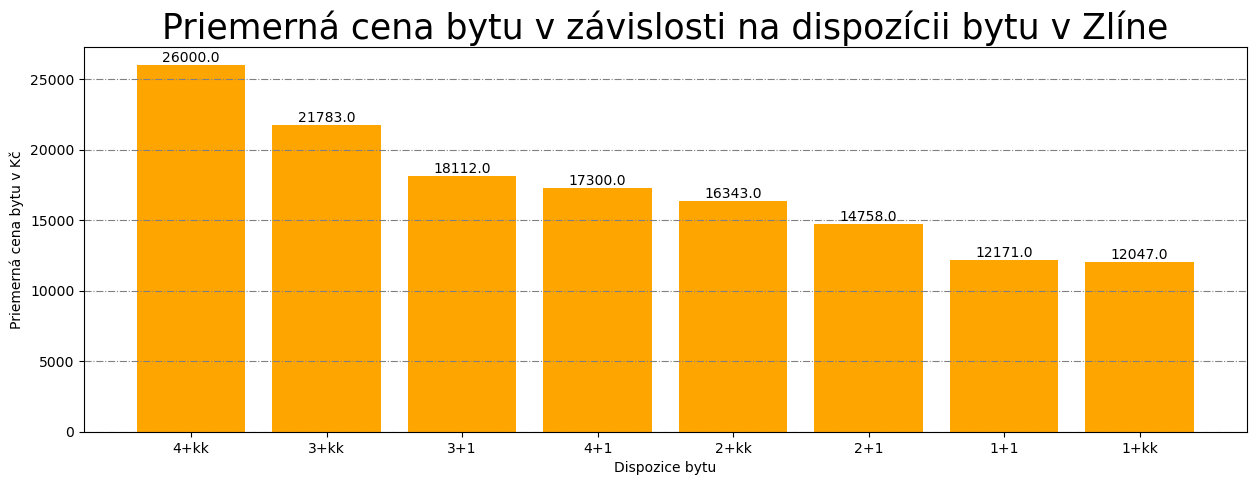

In [5]:
import matplotlib.pyplot as plt

# do parametra labels si davam nazvy dispozicii a kedze budem potrebovat list tak si to prevediem do listu
labels = df_avg_dispozice_bytu['Dispozice bytu'].to_list()

# definujem velkost grafu
plt.figure(figsize=(15,5))

# vytvaram graf, kde na osi X budu dispozicie bytu ako indexy a na osi Y priemerna cena bytu
bars = plt.bar(df_avg_dispozice_bytu.index, df_avg_dispozice_bytu['Priemerna cena bytu'], color="orange")

# hodnoty na osi X a nazvy
plt.xticks(ticks=df_avg_dispozice_bytu.index, labels=labels)

# popis osi Y
plt.ylabel(ylabel="Priemerná cena bytu v Kč", loc="center")

# popis osi X
plt.xlabel("Dispozice bytu")

# nazov grafu
plt.title("Priemerná cena bytu v závislosti na dispozícii bytu v Zlíne", fontsize=25)

# grid (mriezka) grafu
plt.grid(axis="y", color="grey", linestyle= "-.")

# pridanie hodnot nad stlpce
plt.bar_label(bars, fmt="%.1f")

# vykreslenie grafu
plt.show()

3. `Jaká je průměrná velikost bytu pro každou dispozici? Zobrazte i na grafu.`

In [6]:
# Zoskupim si data podla dispozicie bytu a urobim priemer rozmerov bytu pre kazdu dispoziciu bytu a zoradim od najvyssej velkosti bytu v m2
df_avg_velkost_bytu = df.groupby(by= "Dispozice bytu")["Rozmery bytu"].mean().round().sort_values(ascending=False).reset_index(name="Priemerna velkost bytu")

#Priemerna velkost bytu pre kazdu dispoziciu bytu je vysledok df_avg_velkost_bytu v tabulke, zoradenej podla najvyssej priemernej velkosti bytu v m2
df_avg_velkost_bytu

,Dispozice bytu,Priemerna velkost bytu
0,4+kk,106.0
1,4+1,96.0
2,3+kk,86.0
3,3+1,72.0
4,2+1,60.0
5,2+kk,54.0
6,1+1,35.0
7,1+kk,35.0


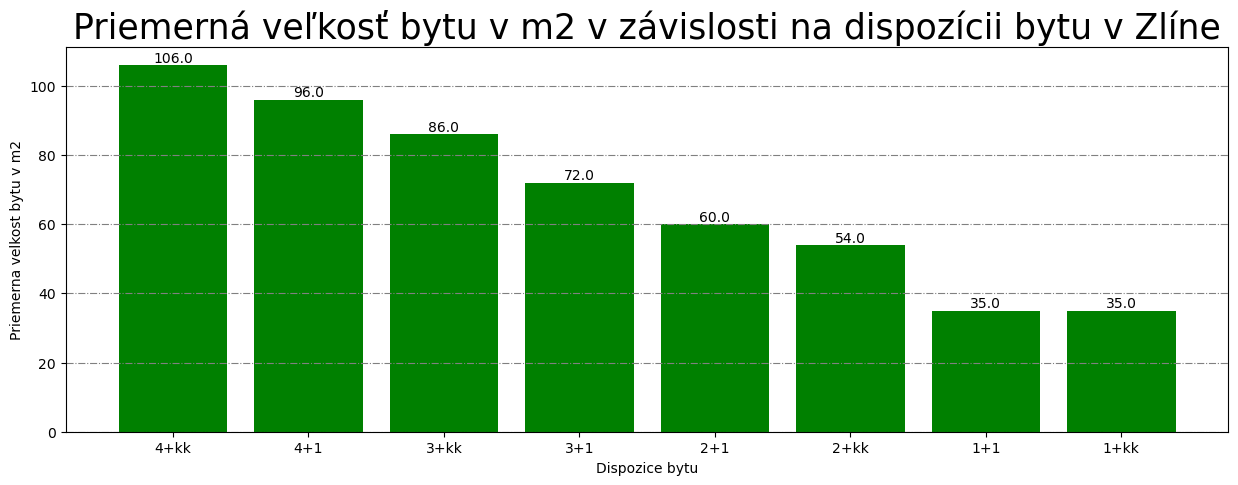

In [7]:
import matplotlib.pyplot as plt

# do parametra labels si davam nazvy dispozicii a kedze budem potrebovat list tak si to prevediem do listu
labels = df_avg_velkost_bytu['Dispozice bytu'].to_list()

# definujem velkost grafu
plt.figure(figsize=(15,5))

# vytvaram graf, kde na osi X budu dispozicie bytu ako indexy a na osi Y priemerna cena bytu
bars = plt.bar(df_avg_velkost_bytu.index, df_avg_velkost_bytu['Priemerna velkost bytu'], color="green")

# hodnoty na osi X a nazvy
plt.xticks(ticks=df_avg_velkost_bytu.index, labels=labels)

# popis osi Y
plt.ylabel(ylabel="Priemerna velkost bytu v m2", loc="center")

# popis osi X
plt.xlabel("Dispozice bytu")

# nazov grafu
plt.title("Priemerná veľkosť bytu v m2 v závislosti na dispozícii bytu v Zlíne", fontsize=25)

# grid (mriezka) grafu
plt.grid(axis="y", color="grey", linestyle= "-.")

# pridanie hodnot nad stlpce
plt.bar_label(bars, fmt="%.1f")

# vykreslenie grafu
plt.show()

4. `Existuje ulice, kde je vyšší koncentrace dražších bytů?` (Definujte "dražší" jako byty nad průměrnou cenou. Zobrazte top 5 ulic s nejvyšší průměrnou cenou, pokud máte dostatek dat.)

In [8]:
# filtrujem cenu bytov vyssiu ako priemerna cena bytov, to su drahsie byty
df_drahsie_byty=df.loc[df["Cena bytu"] > df["Cena bytu"].mean().round()]

# zistim pocet drahsich bytov pre jednotlive ulice a zoradim od ulic s najvyssim poctom drahsich bytov a zobrazim 5 ulic kde je najviac drahsich bytov
# Ano, ulica Nad Stráněmi je ulica, kde je vyssia koncentracia drahsich bytov (8 bytov)
df_drahsie_byty["Lokace bytu_ulica"].value_counts(ascending=False).nlargest(n=5).reset_index(name="Pocet bytov")

,Lokace bytu_ulica,Pocet bytov
0,Nad Stráněmi,8
1,Díly III,4
2,třída Tomáše Bati,4
3,Mostní,3
4,Zelinova,3


5. `Jaký typ dispozice je v daném městě nejčastěji inzerován? Který to je? Proč myslíte, že tomu tak je?` (Zobrazte na grafu - např. bar chart nebo pie chart)

In [9]:
#Zistim pocet bytov pre jednotlive dispozicie bytov
df_dispozice_bytov_pocet = df["Dispozice bytu"].value_counts(ascending=False).reset_index(name="Pocet bytov")

#Najcastejsie su inzerovane dispozicne male byty 1+kk. Je to preto, ze ludia, ktori si hladaju byvanie su single a chcu byvat vacsinou sami a hladaju si presne tieto male typy bytov, alebo druhy dovod je to, ze tieto byty su najlacnejsie
df_dispozice_bytov_pocet

,Dispozice bytu,Pocet bytov
0,1+kk,40
1,2+kk,31
2,2+1,24
3,1+1,21
4,3+kk,18
5,3+1,16
6,4+1,4
7,4+kk,2


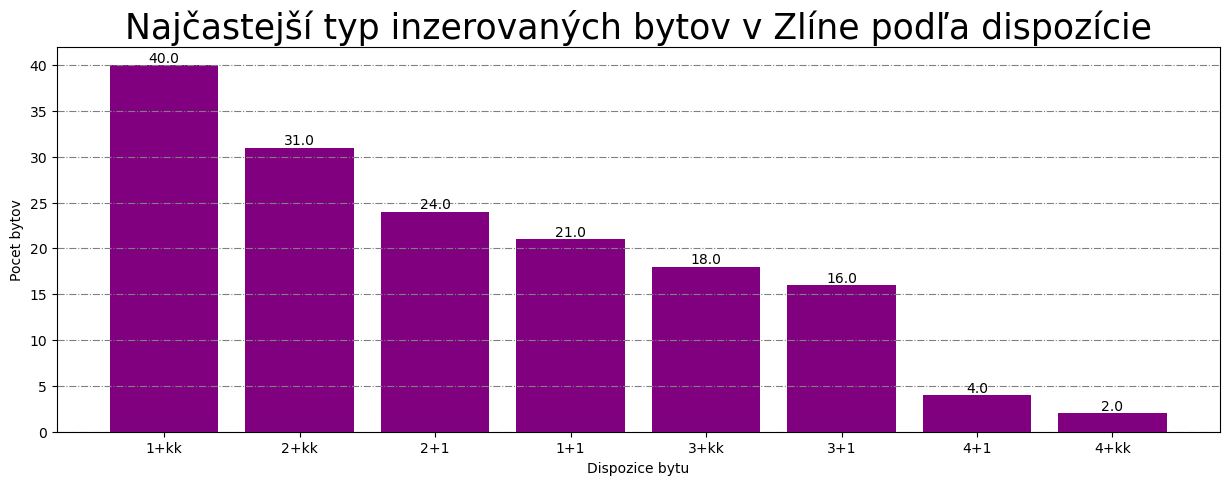

In [11]:
import matplotlib.pyplot as plt

# do parametra labels si davam nazvy dispozicii a kedze budem potrebovat list tak si to prevediem do listu
labels = df_dispozice_bytov_pocet['Dispozice bytu'].to_list()

# definujem velkost grafu
plt.figure(figsize=(15,5))

# vytvaram graf, kde na osi X budu dispozicie bytu ako indexy a na osi Y priemerna cena bytu
bars = plt.bar(df_dispozice_bytov_pocet.index, df_dispozice_bytov_pocet['Pocet bytov'], color="purple")

# hodnoty na osi X a nazvy
plt.xticks(ticks=df_dispozice_bytov_pocet.index, labels=labels)

# popis osi Y
plt.ylabel(ylabel="Pocet bytov", loc="center")

# popis osi X
plt.xlabel("Dispozice bytu")

# nazov grafu
plt.title("Najčastejší typ inzerovaných bytov v Zlíne podľa dispozície", fontsize=25)

# grid (mriezka) grafu
plt.grid(axis="y", color="grey", linestyle= "-.")

# pridanie hodnot nad stlpce
plt.bar_label(bars, fmt="%.1f")

# vykreslenie grafu
plt.show()

6. `Existují zde inzerce bytů, které stojí více než 20.000,- Kč? Pokud ano, jsou v této cenové hladině inzerovány i maximálně dvoupokojové byty (2+1/2+kk)?`

In [26]:
# filtrujem cenu bytov vyssiu ako 20 000kc
df_byty_nad_20k = df.loc[df["Cena bytu"] > 20000]

# Ano, existuju aj inzercie bytov, ktore stoja viac ako 20 000 kc.
df_byty_nad_20k

,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto
13,https://www.sreality.cz/detail/pronajem/byt/2+...,62.0,2+kk,21000.0,Zadní luhy,Zlín - Louky
16,https://www.sreality.cz/detail/pronajem/byt/2+...,120.0,2+1,20500.0,Nivy II,Zlín
39,https://www.sreality.cz/detail/pronajem/byt/3+...,119.0,3+kk,29000.0,Sýkory II,Zlín - Prštné
53,https://www.sreality.cz/detail/pronajem/byt/3+...,82.0,3+kk,25000.0,Jarolímkovo náměstí,Zlín - Malenovice
56,https://www.sreality.cz/detail/pronajem/byt/3+...,92.0,3+kk,30700.0,Díly III,Zlín
68,https://www.sreality.cz/detail/pronajem/byt/4+...,127.0,4+kk,33000.0,Havlíčkovo nábřeží,Zlín
72,https://www.sreality.cz/detail/pronajem/byt/2+...,52.0,2+kk,20650.0,Štefánikova,Zlín
89,https://www.sreality.cz/detail/pronajem/byt/3+...,76.0,3+1,25500.0,třída Tomáše Bati,Zlín
99,https://www.sreality.cz/detail/pronajem/byt/3+...,86.0,3+kk,23000.0,Mostní,Zlín
105,https://www.sreality.cz/detail/pronajem/byt/3+...,76.0,3+1,21000.0,Luční,Zlín


In [29]:
# zistim pocet bytov pre jednotlive dispozicie bytu s cenou vyssou ako 20 ooo kc
df_viac_pokojove_byty_pocet = df_byty_nad_20k["Dispozice bytu"].value_counts(ascending=False).nlargest(n=8).reset_index(name="Pocet bytov")

# Z tabulky df_viac_pokojove_byty_pocet vidim, ze v tejto cenovej hladine su inzerovane aj maximalne dvojpokojove byty (2+1/2+kk) a su to tri byty.
df_viac_pokojove_byty_pocet 

,Dispozice bytu,Pocet bytov
0,3+kk,11
1,3+1,3
2,2+kk,2
3,2+1,1
4,4+kk,1


In [30]:
# Ine riesenie tohto dotazu:
# Vyfiltrujem si byty, ktore stoja viac ako 20 000kc a zaroven maju dispoziciu bytu 2+1 alebo 2+kk a dostanem 3 byty so vsetkymi informaciami z df
df_byty_nad_20k = df.loc[(df["Cena bytu"] > 20000) & (df["Dispozice bytu"].isin(["2+1", "2+kk"]))]

df_byty_nad_20k

,URL odkaz bytu,Rozmery bytu,Dispozice bytu,Cena bytu,Lokace bytu_ulica,Lokace bytu_mesto
13,https://www.sreality.cz/detail/pronajem/byt/2+...,62.0,2+kk,21000.0,Zadní luhy,Zlín - Louky
16,https://www.sreality.cz/detail/pronajem/byt/2+...,120.0,2+1,20500.0,Nivy II,Zlín
72,https://www.sreality.cz/detail/pronajem/byt/2+...,52.0,2+kk,20650.0,Štefánikova,Zlín


7. `Zjištěte minimální a maximální cenu inzerce pro každou dispozici bytu. Která dispozice má největší rozptyl mezi minimální a maximální inzerovanou cenou?` (Zobrazte i na grafu)

In [73]:
# Zoskupim si byty podla dispozicie bytu a zistim minimalnu cenu bytu pre kazdu kategoriu bytov
df_min_cena = df.groupby(by= "Dispozice bytu")["Cena bytu"].min().reset_index(name="Minimalna cena bytu")

# Zoskupim si byty podla dispozicie bytu a zistim maximalnu cenu bytu pre kazdu kategoriu bytov
df_max_cena = df.groupby(by= "Dispozice bytu")["Cena bytu"].max().reset_index(name="Maximalna cena bytu")

# Spojim tabulku s minimalnou cenou bytov a maximalnou cenou bytov do jednej tabulky
df_min_max_cena = pd.merge(left=df_min_cena, right=df_max_cena, left_on="Dispozice bytu", right_on="Dispozice bytu", how="inner")

# Vytvorim novy stlpec pre rozdiel medzi maximalnou a minimalnou cenou bytov
df_min_max_cena["Rozdiel cien"] = df_min_max_cena["Maximalna cena bytu"] - df_min_max_cena["Minimalna cena bytu"]

# Zoradim si dispozicie bytu podla rozdielu cien od najvacsieho rozdielu po najmensi
# Najvacsi rozptyl medzi minimalnou a maximalnou inzerovanou cenou ma dispozicia bytu 3+kk
df_min_max_cena_desc = df_min_max_cena.sort_values(by="Rozdiel cien", ascending=False).reset_index()

df_min_max_cena_desc

,index,Dispozice bytu,Minimalna cena bytu,Maximalna cena bytu,Rozdiel cien
0,5,3+kk,12500.0,33000.0,20500.0
1,7,4+kk,19000.0,33000.0,14000.0
2,4,3+1,13300.0,26000.0,12700.0
3,3,2+kk,9500.0,21000.0,11500.0
4,2,2+1,11000.0,20500.0,9500.0
5,1,1+kk,8000.0,14900.0,6900.0
6,0,1+1,9500.0,15500.0,6000.0
7,6,4+1,15000.0,19900.0,4900.0


In [74]:
import pandas as pd
import plotly.express as px

# do parametra labels si davam nazvy dispozicii a kedze budem potrebovat list tak si to prevediem do listu
labels = df_avg_velkost_bytu['Dispozice bytu'].to_list()

fig = px.bar(
    # DF s ktorym pracujem
    df_min_max_cena_desc,
    # osa X
    x='Dispozice bytu', 
    # osa Y - v tomto prípade list lebo posielam 2
    y=['Minimalna cena bytu', 'Maximalna cena bytu'],
    
    # zmena modu grafu na group
    barmode='group',
    
    # premenovanie labelov
    labels={'variable': 'Ceny bytov:', 'value': 'Ceny bytov v tisicoch'},
    
    # Automaticky prida hodnoty na stlpce
    text_auto=True 
)
# pridavam nazov grafu, jeho umiestnenie do stredu a velkost pisma
fig.update_layout(title={"text": "Min a Max cena bytu v závislosti na dispozícii bytu v Zlíne", "x": 0.5, "xanchor": "center", "font": {"size": 24 } })


fig.update_traces(
    # Zobrazí text nad stlpcami
    textposition='outside', 
    # Zobrazi celu hodnotu
    texttemplate='%{y:.0f}'  
)

fig.show()

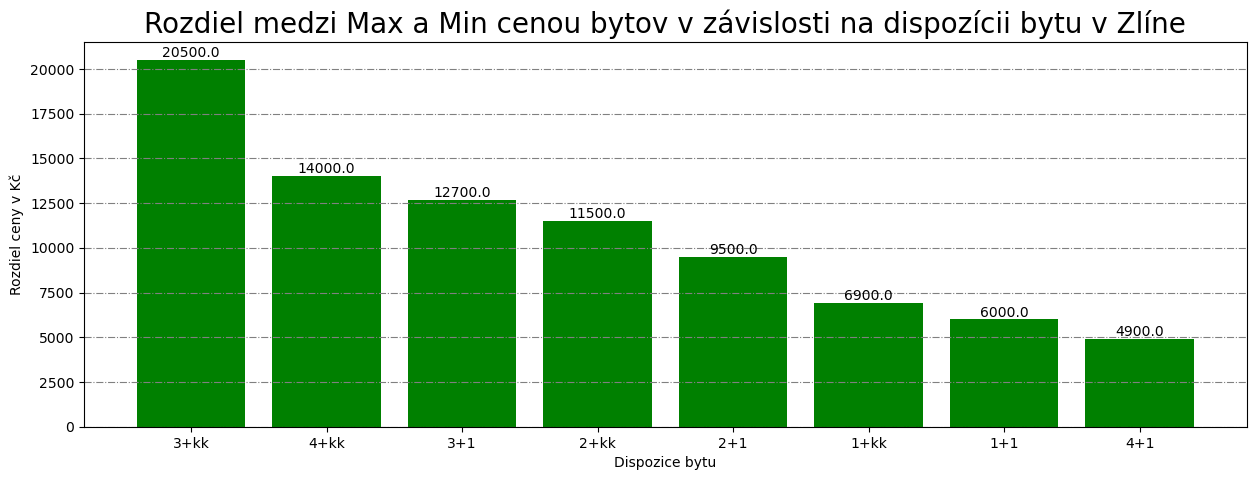

In [81]:
import matplotlib.pyplot as plt

# do parametra labels si davam nazvy dispozicii a kedze budem potrebovat list tak si to prevediem do listu
labels = df_min_max_cena_desc['Dispozice bytu'].to_list()

# definujem velkost grafu
plt.figure(figsize=(15,5))

# vytvaram graf, kde na osi X budu dispozicie bytu ako indexy a na osi Y priemerna cena bytu
bars = plt.bar(df_min_max_cena_desc.index, df_min_max_cena_desc['Rozdiel cien'], color="green")

# hodnoty na osi X a nazvy
plt.xticks(ticks=df_min_max_cena_desc.index, labels=labels)

# popis osi Y
plt.ylabel(ylabel="Rozdiel ceny v Kč", loc="center")

# popis osi X
plt.xlabel("Dispozice bytu")

# nazov grafu
plt.title("Rozdiel medzi Max a Min cenou bytov v závislosti na dispozícii bytu v Zlíne", fontsize=20)

# grid (mriezka) grafu
plt.grid(axis="y", color="grey", linestyle= "-.")

# pridanie hodnot nad stlpce
plt.bar_label(bars, fmt="%.1f")

# vykreslenie grafu
plt.show()